# Mindestanforderungen 2 - Datenexploration

In [61]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

In [62]:
DATA_PATH = Path("output_woche1.csv")

df = pd.read_csv(DATA_PATH)

print("Shape:", df.shape)
df.head()

Shape: (32535, 170)


,ResponseId,MainBranch,Age,EdLevel,Employment,Country,EmploymentAddl,WorkExp,LearnCodeChoose,LearnCode,...,AIAgentOrchestration,AIAgentOrchWrite,AIAgentObserveSecure,AIAgentExternal,AIAgentExtWrite,AIHuman,AIOpen,ConvertedCompYearly,ConvertedCompMonthly,JobSatisfaction
0,1,I am a developer by profession,25-34 years old,Master’s degree,Employed,Ukraine,"Caring for dependents (children, elderly, etc.)",8.0,"Yes, I am not new to coding but am learning ne...",Online Courses or Certification (includes all ...,...,Vertex AI,NaN,NaN,ChatGPT,NaN,When I don’t trust AI’s answers,"Troubleshooting, profiling, debugging",61256.0,5104.666667,10.0
1,2,I am a developer by profession,25-34 years old,Associate degree,Employed,Netherlands,NaN,2.0,"Yes, I am not new to coding but am learning ne...",Online Courses or Certification (includes all ...,...,NaN,NaN,NaN,NaN,NaN,When I don’t trust AI’s answers;When I want to...,All skills. AI is a flop.,104413.0,8701.083333,9.0
2,3,I am a developer by profession,35-44 years old,Bachelor’s degree,"Independent contractor, freelancer, or self-em...",Ukraine,None of the above,10.0,"Yes, I am not new to coding but am learning ne...",Online Courses or Certification (includes all ...,...,NaN,NaN,NaN,ChatGPT;Claude Code;GitHub Copilot;Google Gemini,NaN,When I don’t trust AI’s answers;When I want to...,"Understand how things actually work, problem s...",53061.0,4421.750000,8.0
3,4,I am a developer by profession,35-44 years old,Bachelor’s degree,Employed,Ukraine,None of the above,4.0,"Yes, I am not new to coding but am learning ne...","Other online resources (e.g. standard search, ...",...,NaN,NaN,NaN,ChatGPT;Claude Code,NaN,When I don’t trust AI’s answers;When I want to...,NaN,36197.0,3016.416667,6.0
4,5,I am a developer by profession,35-44 years old,Master’s degree,"Independent contractor, freelancer, or self-em...",Ukraine,"Caring for dependents (children, elderly, etc.)",21.0,"No, I am not new to coding and did not learn n...",NaN,...,NaN,NaN,NaN,NaN,NaN,When I don’t trust AI’s answers,"critical thinking, the skill to define the tas...",60000.0,5000.000000,7.0


SO*-Spalten beziehen sich auf StackOverflow-Plattformfunktionen und sind für unsere Recruiting-Fragestellung (Profile, Skills, Präferenzen, Vergütung) nicht relevant.

In [63]:
so_cols = df.columns[df.columns.str.startswith("SO")]
df = df.drop(columns=so_cols)

print("Dropped SO columns:", len(so_cols))

Dropped SO columns: 23


In [64]:
df_sorted = df.copy()
df_sorted["YearsCode"] = pd.to_numeric(df_sorted["YearsCode"], errors="coerce")

df_sorted = df_sorted.sort_values("YearsCode", ascending=True)
df_sorted[["YearsCode", "Age", "JobSatisfaction", "WorkExp"]].head(20)


,YearsCode,Age,JobSatisfaction,WorkExp
4398,1.0,35-44 years old,8.0,10.0
32437,1.0,18-24 years old,NaN,1.0
27884,1.0,35-44 years old,NaN,21.0
29387,1.0,25-34 years old,NaN,9.0
31075,1.0,35-44 years old,NaN,8.0
27926,1.0,18-24 years old,NaN,NaN
10050,1.0,18-24 years old,NaN,1.0
22514,1.0,65 years or older,NaN,50.0
29348,1.0,35-44 years old,NaN,9.0
24695,1.0,35-44 years old,NaN,20.0


Sortierung nach YearsCode hilft, Erfahrungsstufen zu vergleichen (Junior → Senior) und später HR-Maßnahmen/Angebote zielgruppenspezifisch abzuleiten.

In [65]:
df_stats = df.copy()
df_stats["YearsCode"] = pd.to_numeric(df_stats["YearsCode"], errors="coerce")

years_code_stats = df_stats["YearsCode"].describe()
median = df_stats["YearsCode"].median()
mode = df_stats["YearsCode"].mode().iloc[0]
iqr = df_stats["YearsCode"].quantile(0.75) - df_stats["YearsCode"].quantile(0.25)

print("Statistische Zusammenfassung - Programmiererfahrung (YearsCode):")
print("----------------------------------------------------")
print(f"Anzahl gültiger Werte: {years_code_stats['count']:.0f}")
print(f"Durchschnitt: {years_code_stats['mean']:.1f} Jahre")
print(f"Median: {median:.1f} Jahre")
print(f"Häufigster Wert (Modus): {mode:.0f} Jahre")
print(f"Standardabweichung: {years_code_stats['std']:.1f} Jahre")
print(f"Minimum: {years_code_stats['min']:.0f} Jahre")
print(f"25%-Quartil: {years_code_stats['25%']:.1f} Jahre")
print(f"75%-Quartil: {years_code_stats['75%']:.1f} Jahre")
print(f"Maximum: {years_code_stats['max']:.0f} Jahre")
print(f"IQR: {iqr:.1f} Jahre")

Statistische Zusammenfassung - Programmiererfahrung (YearsCode):
----------------------------------------------------
Anzahl gültiger Werte: 28981
Durchschnitt: 16.8 Jahre
Median: 14.0 Jahre
Häufigster Wert (Modus): 10 Jahre
Standardabweichung: 11.7 Jahre
Minimum: 1 Jahre
25%-Quartil: 8.0 Jahre
75%-Quartil: 24.0 Jahre
Maximum: 100 Jahre
IQR: 16.0 Jahre


- RemoteWork ist für Recruiting relevant, da Arbeitsmodelle (Remote/Hybrid/Onsite) mit Präferenzen und ggf. Gehalt/Zufriedenheit zusammenhängen können
- `In-Person` hat hier geringsten salary-median; `Remote` schneidet am besten ab
- die Tabelle zeigt die Mediane (Salary/JobSatisfaction) je Arbeitsmodell im Datensatz – Interpretation daher deskriptiv, nicht kausal.

In [66]:
df_grp = df.copy()
df_grp["ConvertedCompYearly"] = pd.to_numeric(df_grp["ConvertedCompYearly"], errors="coerce")
df_grp["JobSatisfaction"] = pd.to_numeric(df_grp["JobSatisfaction"], errors="coerce")

grouped = df_grp.groupby("RemoteWork").agg(
    count=("RemoteWork", "count"),
    salary_median=("ConvertedCompYearly", "median"),
    jobsat_median=("JobSatisfaction", "median")
).sort_values("count", ascending=False)

grouped

,count,salary_median,jobsat_median
RemoteWork,,,
Remote,7489,91015.5,8.0
"Hybrid (some remote, leans heavy to in-person)",4492,74249.0,7.0
In-person,3962,48931.0,7.0
"Hybrid (some in-person, leans heavy to flexibility)",3949,81210.0,8.0
"Your choice (very flexible, you can come in when you want or just as needed)",2886,76570.0,8.0


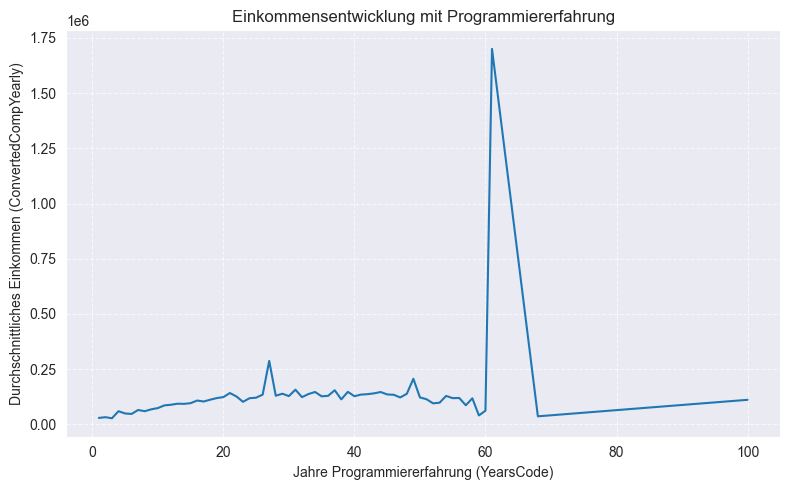

In [67]:
df_line = df.copy()
df_line["YearsCode"] = pd.to_numeric(df_line["YearsCode"], errors="coerce")
df_line["ConvertedCompYearly"] = pd.to_numeric(df_line["ConvertedCompYearly"], errors="coerce")

avg_income = df_line.groupby("YearsCode")["ConvertedCompYearly"].mean().dropna()
avg_income = avg_income.sort_index()

fig, ax = plt.subplots(figsize=(8,5))
ax.plot(avg_income.index, avg_income.values)

ax.set_xlabel("Jahre Programmiererfahrung (YearsCode)")
ax.set_ylabel("Durchschnittliches Einkommen (ConvertedCompYearly)")
ax.set_title("Einkommensentwicklung mit Programmiererfahrung")
ax.grid(True, linestyle="--", alpha=0.7)
plt.tight_layout()

plt.show()

- Mit zunehmender Erfahrung steigt das durchschnittliche Einkommen tendenziell
- Streuung/Ausreißer sind möglich; Aussage ist aggregiert (Mean) und nicht kausal



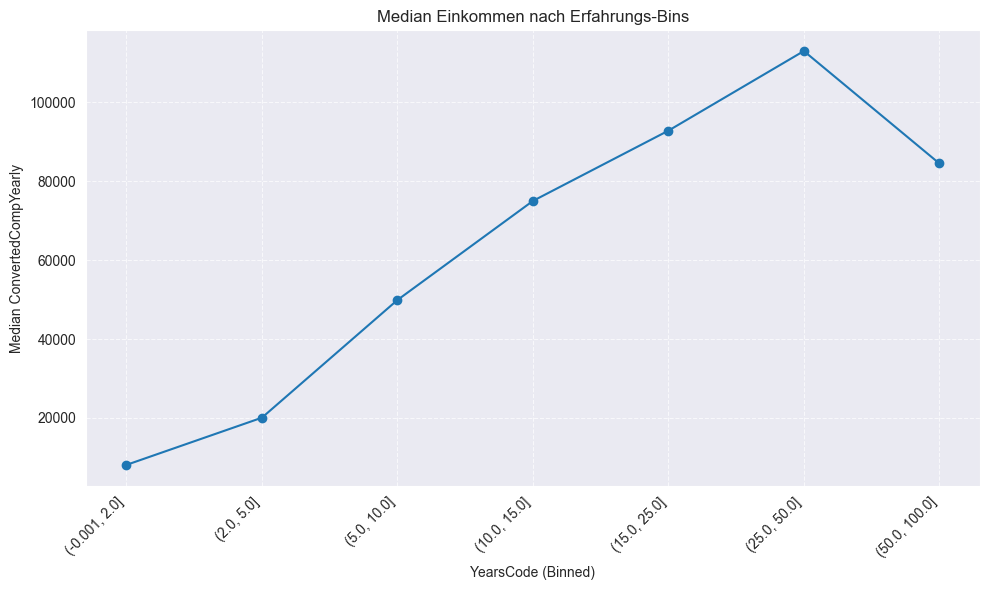

In [68]:
tmp = df[["YearsCode", "ConvertedCompYearly"]].copy()
tmp["YearsCode"] = pd.to_numeric(tmp["YearsCode"], errors="coerce")
tmp["ConvertedCompYearly"] = pd.to_numeric(tmp["ConvertedCompYearly"], errors="coerce")
tmp = tmp.dropna(subset=["YearsCode", "ConvertedCompYearly"])

bins = [0, 2, 5, 10, 15, 25, 50, 100]
tmp["YearsBin"] = pd.cut(tmp["YearsCode"], bins=bins, include_lowest=True)

med_income = tmp.groupby("YearsBin", observed=True)["ConvertedCompYearly"].median()

fig, ax = plt.subplots(figsize=(10,6))
ax.plot(med_income.index.astype(str), med_income.values, marker="o")
ax.set_title("Median Einkommen nach Erfahrungs-Bins")
ax.set_xlabel("YearsCode (Binned)")
ax.set_ylabel("Median ConvertedCompYearly")
ax.grid(True, linestyle="--", alpha=0.7)
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

- Median ist robuster gegen Ausreißer als Mean und somit besser geeignet für Gehaltsband-Argumentation
- Erfahrung wirkt als starker Treiber für Vergütung (aggregiert)

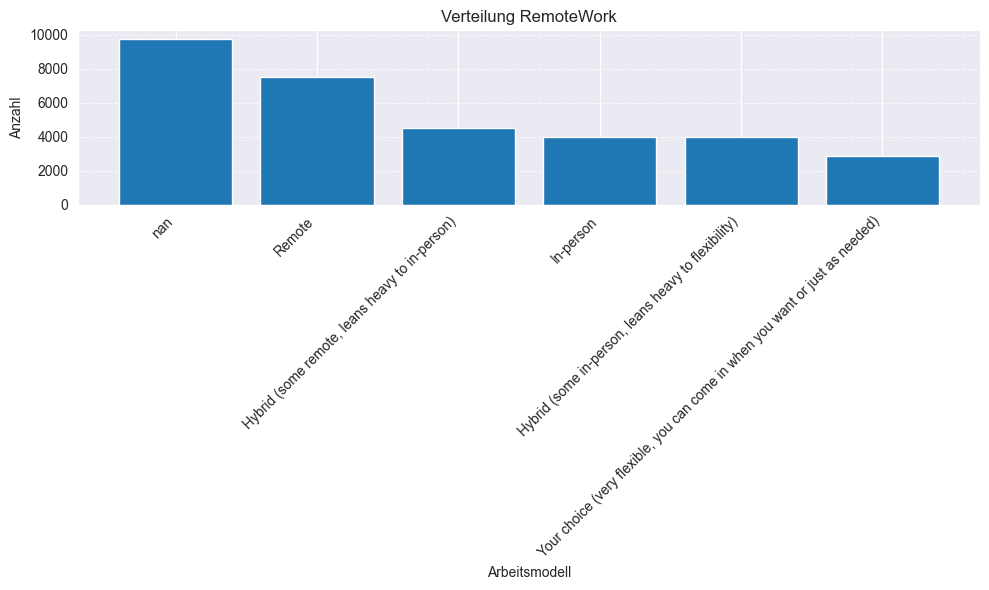

In [69]:
counts = df["RemoteWork"].value_counts(dropna=False)

fig, ax = plt.subplots(figsize=(10,6))
ax.bar(counts.index.astype(str), counts.values)
ax.set_title("Verteilung RemoteWork")
ax.set_xlabel("Arbeitsmodell")
ax.set_ylabel("Anzahl")
ax.grid(True, axis="y", linestyle="--", alpha=0.7)
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


- Zeigt, welche Arbeitsmodelle im Datensatz dominieren
- Relevant für Recruiting: Stellenanzeigen sollten Arbeitsmodell klar kommunizieren, weil es stark nachgefragt sein kann

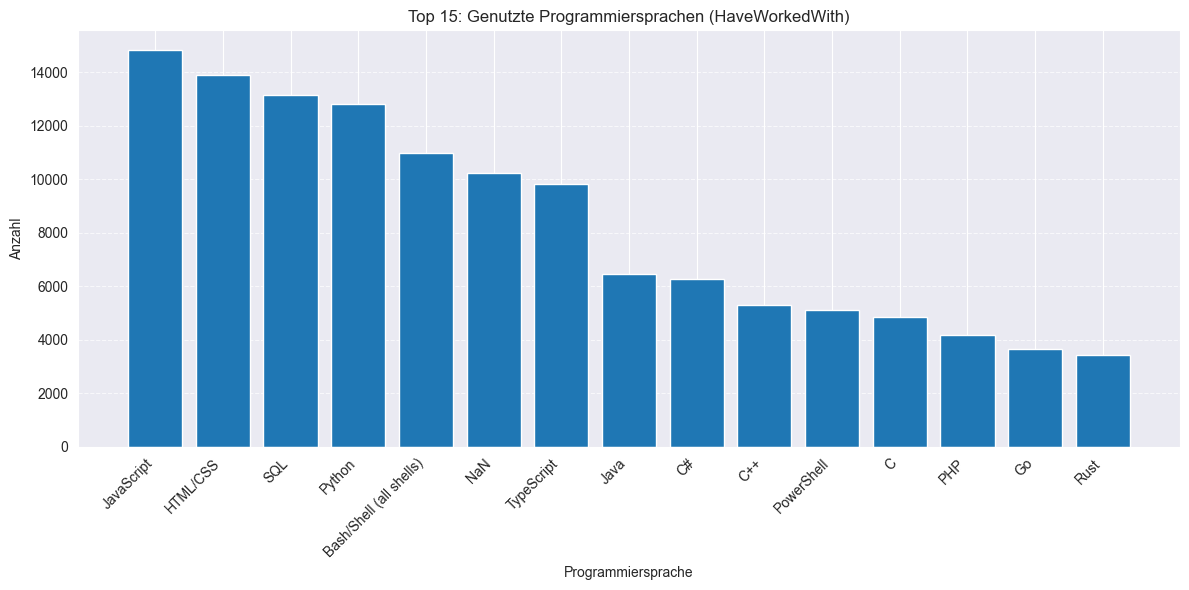

LanguageHaveWorkedWith
JavaScript                 14817
HTML/CSS                   13896
SQL                        13127
Python                     12826
Bash/Shell (all shells)    10975
NaN                        10237
TypeScript                  9805
Java                        6455
C#                          6287
C++                         5283
PowerShell                  5126
C                           4865
PHP                         4160
Go                          3670
Rust                        3425
Name: count, dtype: int64

In [70]:
lang_series = df["LanguageHaveWorkedWith"].fillna("NaN").astype(str).str.split(";")
lang_exploded = lang_series.explode()

lang_counts = lang_exploded.value_counts().head(15)

fig, ax = plt.subplots(figsize=(12,6))
ax.bar(lang_counts.index.astype(str), lang_counts.values)
ax.set_title("Top 15: Genutzte Programmiersprachen (HaveWorkedWith)")
ax.set_xlabel("Programmiersprache")
ax.set_ylabel("Anzahl")
ax.grid(True, axis="y", linestyle="--", alpha=0.7)
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

lang_counts

- Zeigt dominante Skill-Stacks im Markt → hilft beim Formulieren von Must-Have/Nice-to-Have Skills
- Long-Tail sichtbar: viele Nischensprachen, die eher rollen-/domänenspezifisch sind

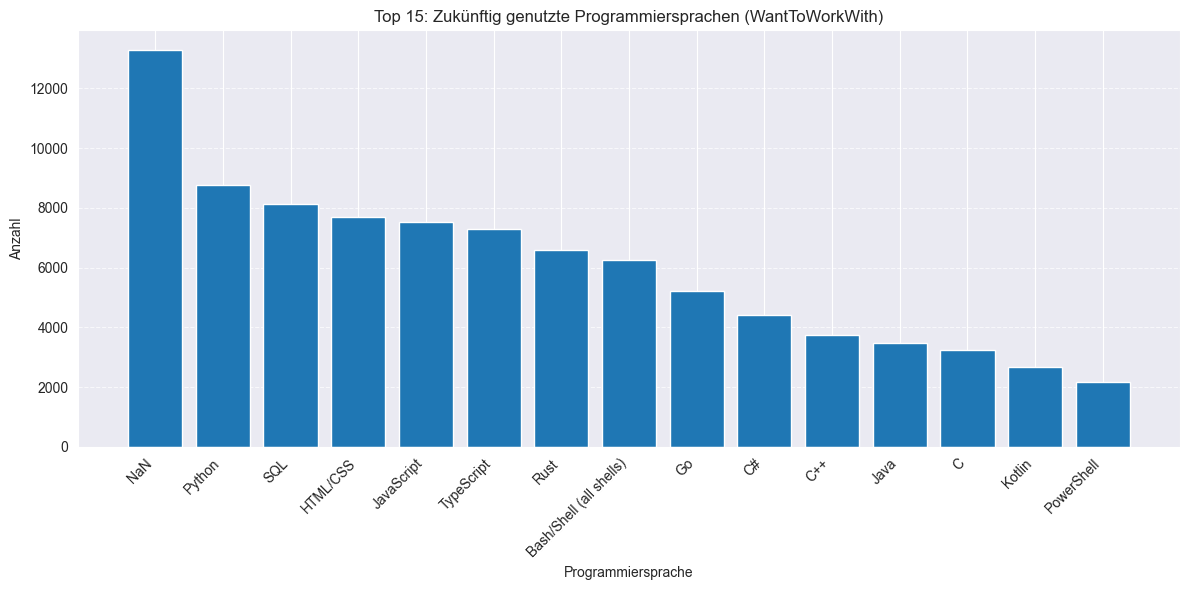

LanguageWantToWorkWith
NaN                        13273
Python                      8751
SQL                         8129
HTML/CSS                    7691
JavaScript                  7539
TypeScript                  7289
Rust                        6573
Bash/Shell (all shells)     6263
Go                          5204
C#                          4422
C++                         3730
Java                        3487
C                           3236
Kotlin                      2677
PowerShell                  2161
Name: count, dtype: int64

In [71]:
lang_series = df["LanguageWantToWorkWith"].fillna("NaN").astype(str).str.split(";")
lang_exploded = lang_series.explode()

lang_counts = lang_exploded.value_counts().head(15)

fig, ax = plt.subplots(figsize=(12,6))
ax.bar(lang_counts.index.astype(str), lang_counts.values)
ax.set_title("Top 15: Zukünftig genutzte Programmiersprachen (WantToWorkWith)")
ax.set_xlabel("Programmiersprache")
ax.set_ylabel("Anzahl")
ax.grid(True, axis="y", linestyle="--", alpha=0.7)
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

lang_counts

- Zeigt Tech-Trends/Präferenzen → hilfreich für Tech-Branding und Zukunfts-Stacks
- Gap Have vs Want kann auf Upskilling-Interesse hinweisen

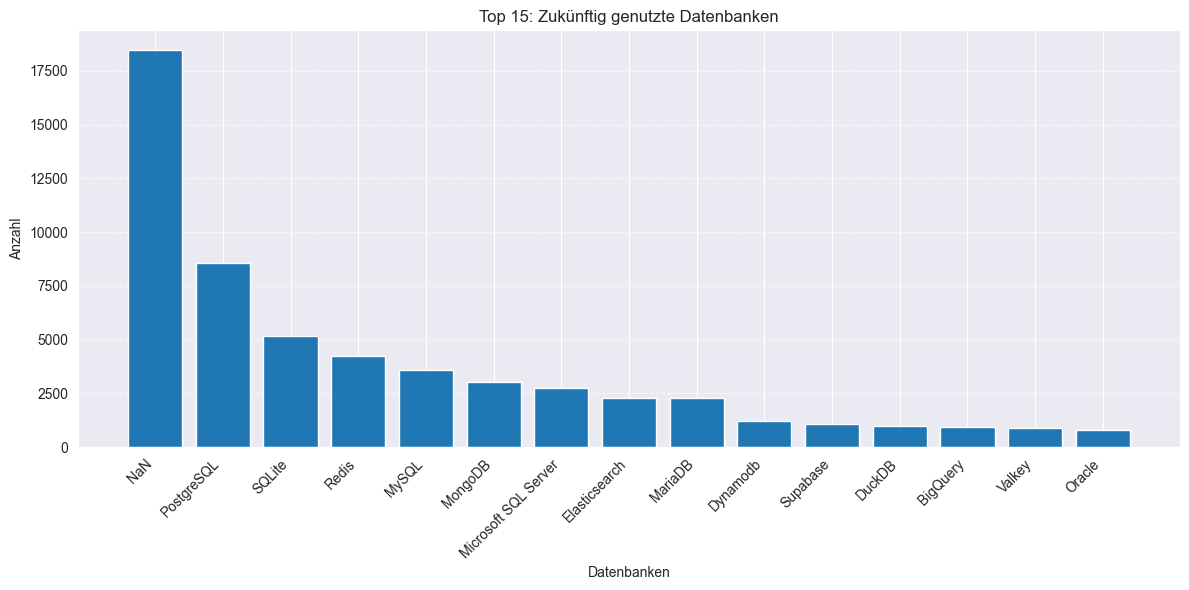

DatabaseWantToWorkWith
NaN                     18454
PostgreSQL               8586
SQLite                   5170
Redis                    4258
MySQL                    3590
MongoDB                  3050
Microsoft SQL Server     2766
Elasticsearch            2308
MariaDB                  2283
Dynamodb                 1223
Supabase                 1082
DuckDB                    987
BigQuery                  935
Valkey                    882
Oracle                    808
Name: count, dtype: int64

In [72]:
lang_series = df["DatabaseWantToWorkWith"].fillna("NaN").astype(str).str.split(";")
lang_exploded = lang_series.explode()

lang_counts = lang_exploded.value_counts().head(15)

fig, ax = plt.subplots(figsize=(12,6))
ax.bar(lang_counts.index.astype(str), lang_counts.values)
ax.set_title("Top 15: Zukünftig genutzte Datenbanken")
ax.set_xlabel("Datenbanken")
ax.set_ylabel("Anzahl")
ax.grid(True, axis="y", linestyle="--", alpha=0.7)
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

lang_counts

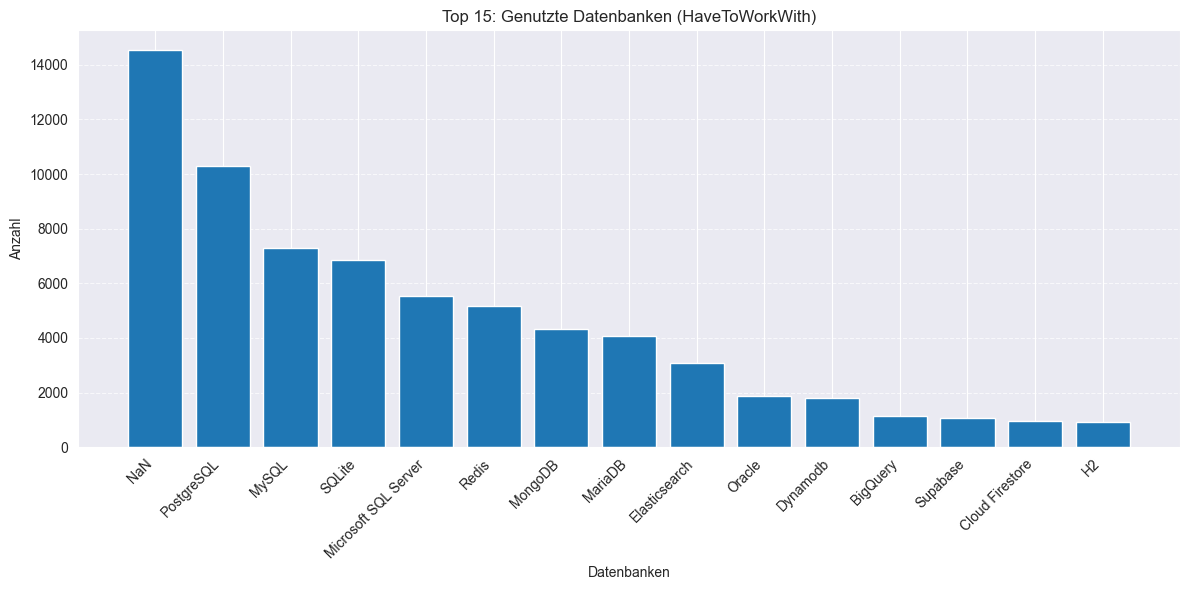

DatabaseHaveWorkedWith
NaN                     14533
PostgreSQL              10289
MySQL                    7296
SQLite                   6840
Microsoft SQL Server     5553
Redis                    5153
MongoDB                  4317
MariaDB                  4085
Elasticsearch            3092
Oracle                   1864
Dynamodb                 1817
BigQuery                 1138
Supabase                 1070
Cloud Firestore           974
H2                        915
Name: count, dtype: int64

In [73]:
lang_series = df["DatabaseHaveWorkedWith"].fillna("NaN").astype(str).str.split(";")
lang_exploded = lang_series.explode()

lang_counts = lang_exploded.value_counts().head(15)

fig, ax = plt.subplots(figsize=(12,6))
ax.bar(lang_counts.index.astype(str), lang_counts.values)
ax.set_title("Top 15: Genutzte Datenbanken (HaveToWorkWith)")
ax.set_xlabel("Datenbanken")
ax.set_ylabel("Anzahl")
ax.grid(True, axis="y", linestyle="--", alpha=0.7)
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

lang_counts

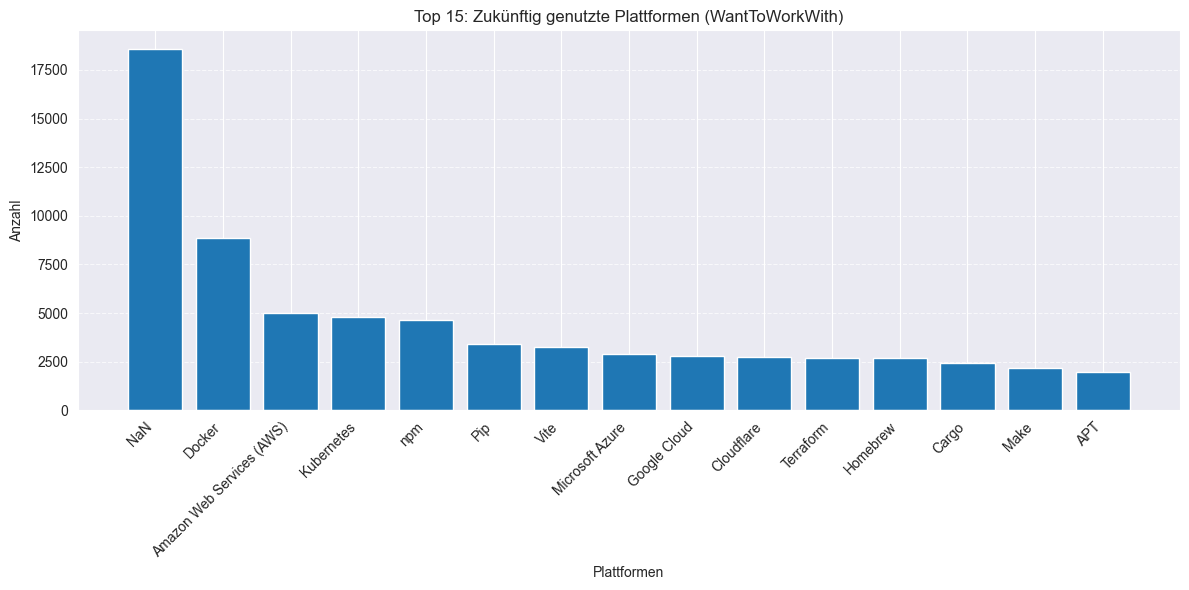

PlatformWantToWorkWith
NaN                          18601
Docker                        8839
Amazon Web Services (AWS)     5017
Kubernetes                    4799
npm                           4658
Pip                           3394
Vite                          3252
Microsoft Azure               2907
Google Cloud                  2773
Cloudflare                    2745
Terraform                     2683
Homebrew                      2669
Cargo                         2431
Make                          2165
APT                           1977
Name: count, dtype: int64

In [74]:
lang_series = df["PlatformWantToWorkWith"].fillna("NaN").astype(str).str.split(";")
lang_exploded = lang_series.explode()

lang_counts = lang_exploded.value_counts().head(15)

fig, ax = plt.subplots(figsize=(12,6))
ax.bar(lang_counts.index.astype(str), lang_counts.values)
ax.set_title("Top 15: Zukünftig genutzte Plattformen (WantToWorkWith)")
ax.set_xlabel("Plattformen")
ax.set_ylabel("Anzahl")
ax.grid(True, axis="y", linestyle="--", alpha=0.7)
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()
lang_counts

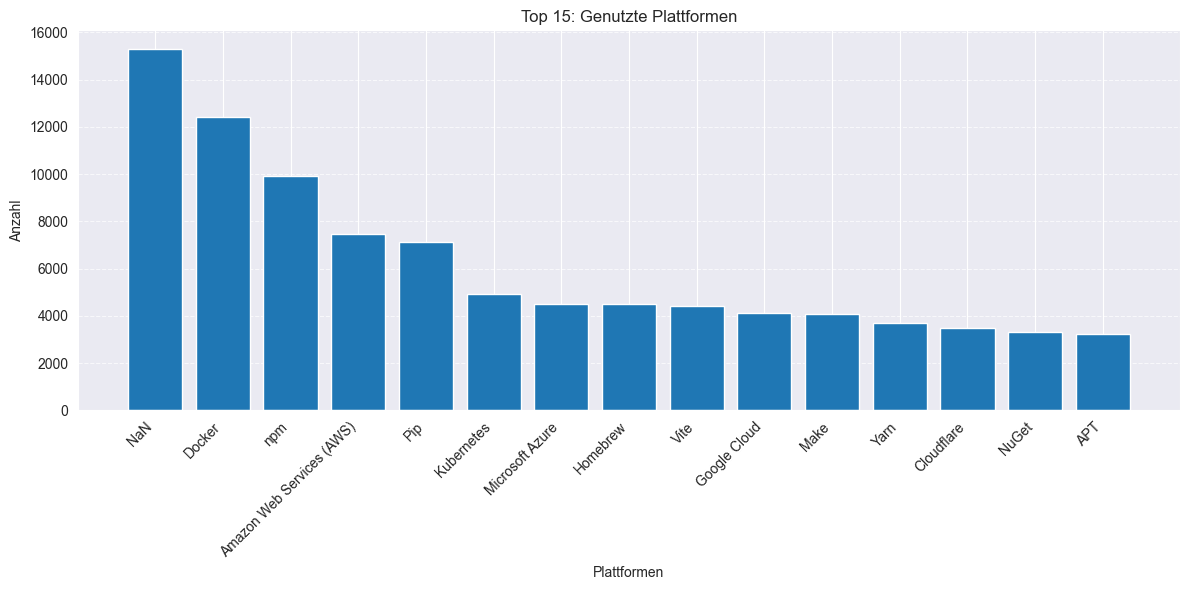

PlatformHaveWorkedWith
NaN                          15315
Docker                       12421
npm                           9923
Amazon Web Services (AWS)     7451
Pip                           7146
Kubernetes                    4931
Microsoft Azure               4521
Homebrew                      4516
Vite                          4435
Google Cloud                  4119
Make                          4074
Yarn                          3683
Cloudflare                    3485
NuGet                         3325
APT                           3235
Name: count, dtype: int64

In [75]:
lang_series = df["PlatformHaveWorkedWith"].fillna("NaN").astype(str).str.split(";")
lang_exploded = lang_series.explode()

lang_counts = lang_exploded.value_counts().head(15)

fig, ax = plt.subplots(figsize=(12,6))
ax.bar(lang_counts.index.astype(str), lang_counts.values)
ax.set_title("Top 15: Genutzte Plattformen")
ax.set_xlabel("Plattformen")
ax.set_ylabel("Anzahl")
ax.grid(True, axis="y", linestyle="--", alpha=0.7)
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()
lang_counts

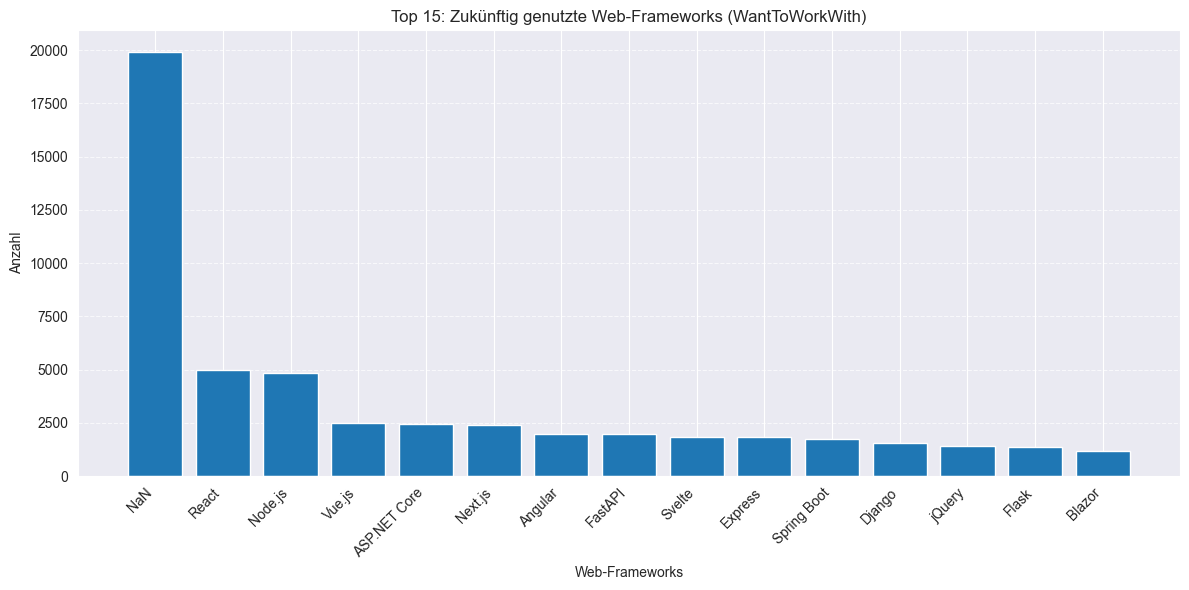

WebframeWantToWorkWith
NaN             19935
React            4961
Node.js          4846
Vue.js           2468
ASP.NET Core     2441
Next.js          2381
Angular          1995
FastAPI          1970
Svelte           1819
Express          1817
Spring Boot      1740
Django           1575
jQuery           1392
Flask            1343
Blazor           1164
Name: count, dtype: int64

In [76]:
lang_series = df["WebframeWantToWorkWith"].fillna("NaN").astype(str).str.split(";")
lang_exploded = lang_series.explode()

lang_counts = lang_exploded.value_counts().head(15)

fig, ax = plt.subplots(figsize=(12,6))
ax.bar(lang_counts.index.astype(str), lang_counts.values)
ax.set_title("Top 15: Zukünftig genutzte Web-Frameworks (WantToWorkWith)")
ax.set_xlabel("Web-Frameworks")
ax.set_ylabel("Anzahl")
ax.grid(True, axis="y", linestyle="--", alpha=0.7)
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

lang_counts

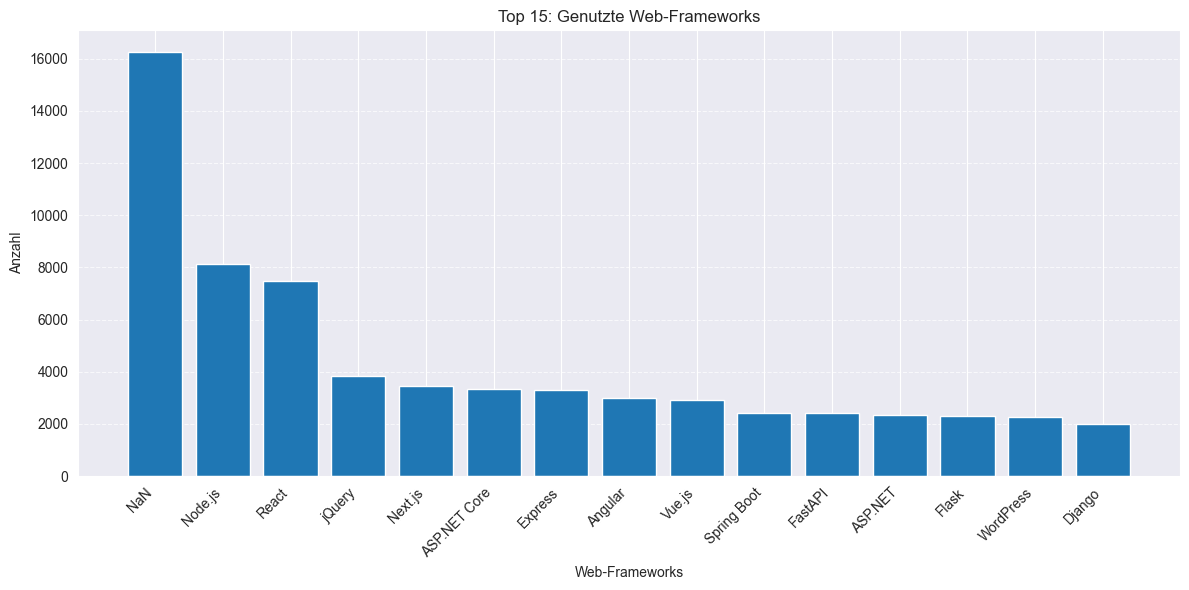

WebframeHaveWorkedWith
NaN             16275
Node.js          8146
React            7472
jQuery           3848
Next.js          3457
ASP.NET Core     3330
Express          3307
Angular          2997
Vue.js           2930
Spring Boot      2422
FastAPI          2402
ASP.NET          2337
Flask            2317
WordPress        2245
Django           2001
Name: count, dtype: int64

In [77]:
lang_series = df["WebframeHaveWorkedWith"].fillna("NaN").astype(str).str.split(";")
lang_exploded = lang_series.explode()

lang_counts = lang_exploded.value_counts().head(15)

fig, ax = plt.subplots(figsize=(12,6))
ax.bar(lang_counts.index.astype(str), lang_counts.values)
ax.set_title("Top 15: Genutzte Web-Frameworks")
ax.set_xlabel("Web-Frameworks")
ax.set_ylabel("Anzahl")
ax.grid(True, axis="y", linestyle="--", alpha=0.7)
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()
lang_counts

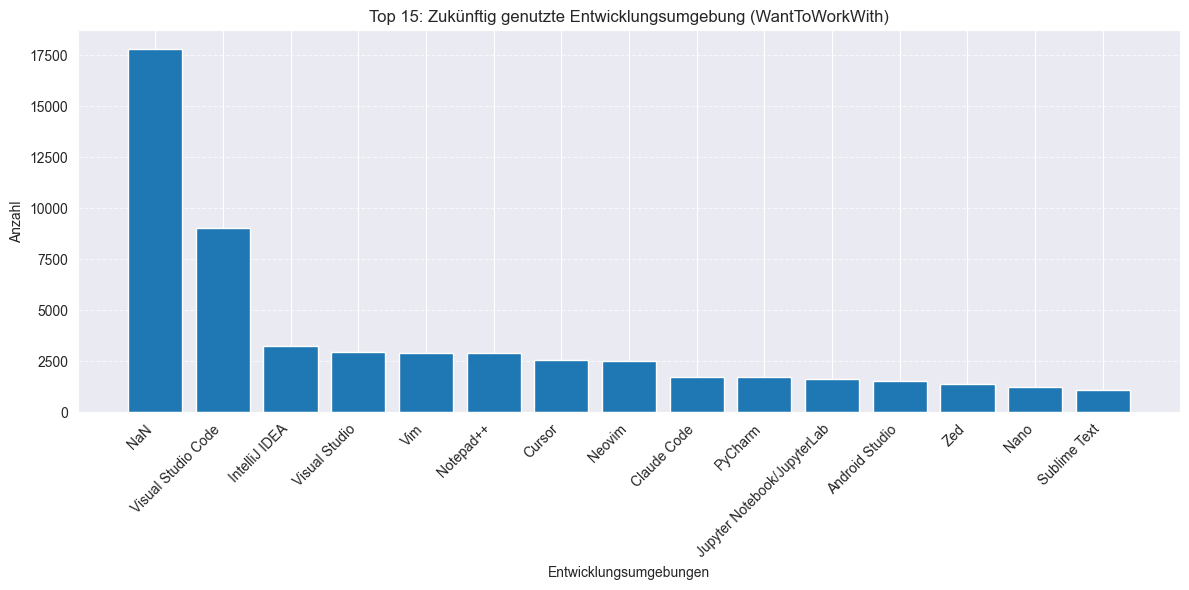

DevEnvsWantToWorkWith
NaN                            17826
Visual Studio Code              9057
IntelliJ IDEA                   3253
Visual Studio                   2956
Vim                             2929
Notepad++                       2894
Cursor                          2590
Neovim                          2515
Claude Code                     1722
PyCharm                         1717
Jupyter Notebook/JupyterLab     1623
Android Studio                  1551
Zed                             1378
Nano                            1225
Sublime Text                    1087
Name: count, dtype: int64

In [78]:
lang_series = df["DevEnvsWantToWorkWith"].fillna("NaN").astype(str).str.split(";")
lang_exploded = lang_series.explode()

lang_counts = lang_exploded.value_counts().head(15)

fig, ax = plt.subplots(figsize=(12,6))
ax.bar(lang_counts.index.astype(str), lang_counts.values)
ax.set_title("Top 15: Zukünftig genutzte Entwicklungsumgebung (WantToWorkWith)")
ax.set_xlabel("Entwicklungsumgebungen")
ax.set_ylabel("Anzahl")
ax.grid(True, axis="y", linestyle="--", alpha=0.7)
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()
lang_counts

In [79]:
lang_series = df["DevEnvsHaveWorkedWith"].fillna("NaN").astype(str).str.split(";")
lang_exploded = lang_series.explode()

lang_counts = lang_exploded.value_counts().head(15)
